# Financial Trading with Python, 2nd Edition
Cordell L. Tanny, CFA, FRM, FDP

Chapter 11: How to Spot a Bad Backtest

Notebook 11.3: Forensic Audit of a Synthetic Flawed Backtest

Version 1.0

Last revised: June 23, 2026

> Save a copy to your own Drive before running (File → Save a copy in Drive).




Imagine you receive a backtest from a colleague. The results look good: solid CAGR, reasonable Sharpe, modest drawdown. Do you trust it?

This notebook walks through a systematic forensic audit of exactly that scenario. We adapt the paired switching strategy from Maewal and Bock (2011) to fit our daily data framework, then intentionally introduce a full-sample normalization error into the signal construction. We present the flawed results as if they arrived from an external source and work through the full audit checklist to expose the problem.

The original paper is available at: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1917044

The strategy rotates between two negatively correlated instruments based on recent relative performance. At each rebalancing point, the investor holds whichever instrument has performed better over the prior period. The idea is that if two assets are negatively correlated, their strong periods tend not to overlap, and a simple momentum rule can capture more of the upside from each while reducing exposure during their respective drawdowns. In our implementation, we use SPY and AGG as the instrument pair and a daily z-score of the 60-day rolling return spread as the switching signal.

The goal is not to show a dramatic fraud. The goal is to build the habit of asking the right questions about any backtest before acting on it.

This notebook covers:

- The paired switching strategy: concept, instruments, and signal construction
- Visualizing the SPY/AGG correlation regime shift that makes this a good teaching example
- Building the flawed and correct versions of the strategy
- Running the forensic checklist: Sharpe, win rate, drawdown profile, trade concentration, and rolling performance
- The normalization audit: detecting the flaw in the data construction
- Before/after comparison: quantifying the impact of the error

## Section 1: Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Parameters ─────────────────────────────────────────────────────────────────
TICKER_EQUITY = 'SPY'
TICKER_BONDS  = 'AGG'
START_DATE    = '2005-01-01'
END_DATE      = '2025-12-31'
TRADING_DAYS  = 252
ROLL_WINDOW   = 60     # rolling window for spread calculation (trading days)
THRESHOLD     = 1.5    # z-score entry/exit threshold

# ── Load SPY and AGG ───────────────────────────────────────────────────────────
raw = yf.download([TICKER_EQUITY, TICKER_BONDS],
                  start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close']
raw = raw.dropna()

# ── Daily simple returns ────────────────────────────────────────────────────────
spy_ret = raw['SPY'].pct_change()
agg_ret = raw['AGG'].pct_change()

# ── 60-day rolling return spread: SPY minus AGG ────────────────────────────────
# Positive values: SPY has outperformed AGG over the past 60 days.
# Negative values: AGG has outperformed SPY.
spy_roll = raw['SPY'].pct_change(ROLL_WINDOW)
agg_roll = raw['AGG'].pct_change(ROLL_WINDOW)
spread   = spy_roll - agg_roll

# ── Build working DataFrame ────────────────────────────────────────────────────
df = pd.DataFrame({
    'SPY_Return': spy_ret,
    'AGG_Return': agg_ret,
    'Spread':     spread
}).dropna()

# ── Rolling correlation ────────────────────────────────────────────────────────
# 252-day rolling correlation between SPY and AGG daily returns.
# Computed here for use in Section 3.
rolling_corr = spy_ret.rolling(TRADING_DAYS).corr(agg_ret)

# ── Summary output ─────────────────────────────────────────────────────────────
print(f"Loaded {len(raw)} trading days: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Working dataset after rolling window: {len(df)} trading days")
print(f"\nSpread statistics:")
print(f"  Mean:   {df['Spread'].mean():.4f}")
print(f"  Std:    {df['Spread'].std():.4f}")
print(f"  Min:    {df['Spread'].min():.4f}")
print(f"  Max:    {df['Spread'].max():.4f}")
print(f"\nSPY/AGG correlation:")
print(f"  Full period: {spy_ret.corr(agg_ret):.4f}")
print(f"  Pre-2022:    {spy_ret[:'2021'].corr(agg_ret[:'2021']):.4f}")
print(f"  Post-2022:   {spy_ret['2022':].corr(agg_ret['2022':]):.4f}")

Loaded 5282 trading days: 2005-01-03 to 2025-12-30
Working dataset after rolling window: 5222 trading days

Spread statistics:
  Mean:   0.0199
  Std:    0.0746
  Min:    -0.3891
  Max:    0.3773

SPY/AGG correlation:
  Full period: -0.0059
  Pre-2022:    -0.0697
  Post-2022:   0.2115


The correlation data confirms the regime shift:

- Pre-2022: SPY and AGG had a correlation of -0.070, the negative relationship that paired switching relies on
- Post-2022: the correlation flipped to +0.212 as both assets sold off simultaneously during the rate hiking cycle
- Full-period: the two effects nearly cancel out to -0.006, which masks the structural break entirely

This is why the full-sample z-score is problematic here. The full-sample mean and standard deviation of the spread incorporate the post-2022 regime, where both assets moved together. A real-time system operating in 2015 or 2018 would have had no knowledge of that regime and would have estimated very different baseline statistics.

Before building the strategy, we visualize this regime shift directly.

## Section 2: Visualizing the Correlation Regime Shift

The rolling 252-day correlation between SPY and AGG makes the regime shift visible. This chart is part of the forensic audit: it explains why the full-sample z-score is particularly misleading for this instrument pair.

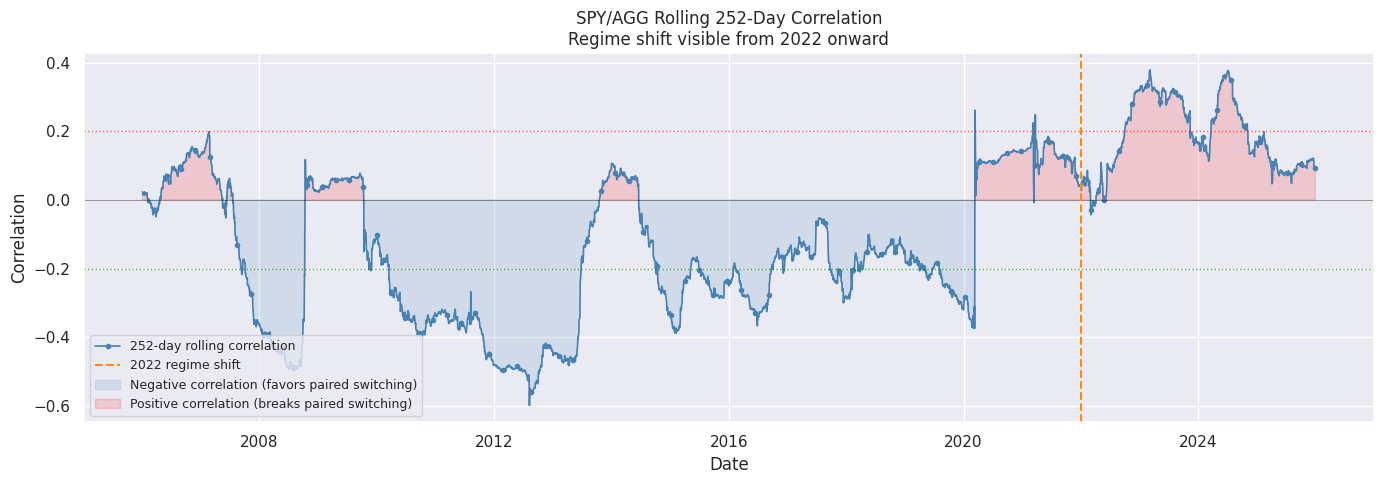

Annual SPY/AGG correlation:
Date
2005    0.0220
2006    0.1350
2007   -0.3610
2008    0.0260
2009   -0.1140
2010   -0.3300
2011   -0.4790
2012   -0.4560
2013    0.1000
2014   -0.3260
2015   -0.2490
2016   -0.1540
2017   -0.2770
2018   -0.1470
2019   -0.3200
2020    0.1430
2021    0.0390
2022    0.3220
2023    0.1610
2024    0.1630
2025    0.0950


In [ ]:
# ── Rolling correlation chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr.index, rolling_corr,
        color='steelblue', linewidth=1.2, linestyle='solid',
        marker='o', markersize=3, markevery=60,
        label='252-day rolling correlation')

# Reference lines
ax.axhline(0,    color='black', linewidth=0.8, linestyle='solid', alpha=0.4)
ax.axhline(0.2,  color='red',   linewidth=1.0, linestyle='dotted', alpha=0.7)
ax.axhline(-0.2, color='green', linewidth=1.0, linestyle='dotted', alpha=0.7)

# Mark the 2022 regime shift
ax.axvline(pd.Timestamp('2022-01-01'), color='darkorange',
           linewidth=1.5, linestyle='dashed', label='2022 regime shift')

ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=rolling_corr < 0,
                color='steelblue', alpha=0.15,
                label='Negative correlation (favors paired switching)')
ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=rolling_corr > 0,
                color='red', alpha=0.15,
                label='Positive correlation (breaks paired switching)')

ax.set_title('SPY/AGG Rolling 252-Day Correlation\nRegime shift visible from 2022 onward')
ax.set_ylabel('Correlation')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_6_spy_agg_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Annual correlation breakdown ───────────────────────────────────────────────
annual_corr = spy_ret.groupby(spy_ret.index.year).apply(
    lambda x: x.corr(agg_ret.loc[x.index])
)
print("Annual SPY/AGG correlation:")
print(annual_corr.round(3).to_string())

The chart and annual correlation table reveal several important features:

- From 2007 through 2019, SPY and AGG were consistently negatively correlated, with annual correlations as low as -0.479 in 2011 and -0.456 in 2012. This is the environment paired switching was designed for.
- 2020 marked the beginning of the breakdown: COVID briefly pushed both assets in the same direction
- 2022 was the inflection point: the correlation jumped to +0.322 as the Fed's aggressive rate hiking cycle drove both equities and bonds lower simultaneously
- 2023-2025 have remained in positive correlation territory, suggesting this is a structural shift rather than a temporary disruption

This matters for our forensic audit in two ways:

- The paired switching strategy's core assumption (negative correlation) held for most of the sample but broke down for the final four years
- The full-sample z-score incorporates the post-2022 regime when computing its baseline statistics, giving every historical signal access to information about a correlation structure that did not exist yet

With this context established, we can now build the flawed and correct versions of the strategy.

## Section 3: Building the Flawed and Correct Strategies

We now build both versions of the paired switching strategy. The only difference between them is how the z-score of the spread is computed:

- Correct version: expanding window mean and standard deviation
- Flawed version: full-sample mean and standard deviation

We reuse the backtest function from notebook 10.1. The strategy logic is identical: rotate to AGG when the z-score is high (SPY has been outperforming, expect mean reversion) and rotate to SPY when the z-score is low.

In [ ]:
# ── Paired switching backtest function ────────────────────────────────────────
def backtest_paired_switching(df: pd.DataFrame, z_col: str, threshold: float,
                              spy_return_col: str, agg_return_col: str,
                              initial_pos: str = 'SPY') -> pd.DataFrame:
    """
    Backtest a paired switching strategy using a z-score signal.

    Signal logic:
    - z > +threshold : SPY has been outperforming, rotate to AGG
    - z < -threshold : AGG has been outperforming, rotate to SPY
    - otherwise      : hold current position

    Parameters:
    -----------
    df              : DataFrame with returns and z-score columns
    z_col           : column name for the z-score series
    threshold       : entry/exit threshold
    spy_return_col  : column name for SPY daily returns
    agg_return_col  : column name for AGG daily returns
    initial_pos     : starting position before first signal fires

    Returns:
    --------
    DataFrame with Position, Strategy_Return, and Cumulative_Return columns.
    """
    df_copy = df.dropna(subset=[z_col]).copy()
    df_copy['Position'] = np.nan

    # Momentum: rotate TO the outperforming asset
    df_copy.loc[df_copy[z_col] >  threshold, 'Position'] = 'SPY'   # SPY outperforming: hold SPY
    df_copy.loc[df_copy[z_col] < -threshold, 'Position'] = 'AGG'   # AGG outperforming: hold AGG

    # Set initial position if no signal fires at the start
    if pd.isna(df_copy['Position'].iloc[0]):
        df_copy.loc[df_copy.index[0], 'Position'] = initial_pos

    # Forward fill: hold current position until next signal
    df_copy['Position'] = df_copy['Position'].ffill()

    # Shift by 1 day: signal on day t executes on day t+1
    df_copy['Position'] = df_copy['Position'].shift(1)
    df_copy = df_copy.dropna(subset=['Position'])

    # Strategy return based on current position
    df_copy['Strategy_Return'] = np.where(
        df_copy['Position'] == 'AGG',
        df_copy[agg_return_col],
        df_copy[spy_return_col]
    )
    df_copy['Strategy_Return'] = df_copy['Strategy_Return'].fillna(0)
    df_copy['Cumulative_Return'] = (1 + df_copy['Strategy_Return']).cumprod() - 1

    return df_copy[['Position', 'Strategy_Return', 'Cumulative_Return']]


# ── Compute both z-scores on the spread ───────────────────────────────────────
# Correct: expanding window
spread_exp_mean   = df['Spread'].expanding().mean()
spread_exp_std    = df['Spread'].expanding().std()
df['Z_Expanding'] = (df['Spread'] - spread_exp_mean) / spread_exp_std

# Flawed: full-sample statistics
# Every historical z-score uses the mean and std of the entire spread series,
# including the post-2022 regime shift data.
df['Z_Fullsample'] = (df['Spread'] - df['Spread'].mean()) / df['Spread'].std()

THRESHOLD = 1.5

# ── Run both backtests ─────────────────────────────────────────────────────────
results_correct = backtest_paired_switching(
    df, z_col='Z_Expanding',   threshold=THRESHOLD,
    spy_return_col='SPY_Return', agg_return_col='AGG_Return'
)

results_flawed = backtest_paired_switching(
    df, z_col='Z_Fullsample',  threshold=THRESHOLD,
    spy_return_col='SPY_Return', agg_return_col='AGG_Return'
)

# ── Metrics ────────────────────────────────────────────────────────────────────
def get_metrics_simple(returns: pd.Series, label: str):
    """Compute and print metrics for a simple return series."""
    log_rets = np.log(1 + returns.clip(lower=-0.9999))
    n_years  = len(returns) / 252
    cagr     = (1 + returns).prod() ** (1 / n_years) - 1
    sharpe   = (log_rets.mean() / log_rets.std()) * np.sqrt(252)
    eq       = (1 + returns).cumprod()
    drawdown = (eq / eq.cummax() - 1).min()
    win_rate = (returns > 0).sum() / (returns != 0).sum()
    print(f"{label}:")
    print(f"  CAGR:         {cagr:.2%}")
    print(f"  Sharpe:       {sharpe:.2f}")
    print(f"  Max Drawdown: {drawdown:.2%}")
    print(f"  Win Rate:     {win_rate:.2%}")
    print()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'Max Drawdown': drawdown, 'Win Rate': win_rate}

# SPY buy-and-hold benchmark
spy_log = np.log(1 + df['SPY_Return'])
n_years_spy = len(spy_log) / 252
spy_cagr    = np.exp(spy_log.sum() / n_years_spy) - 1
spy_sharpe  = (spy_log.mean() / spy_log.std()) * np.sqrt(252)
spy_dd      = ((1 + df['SPY_Return']).cumprod() / (1 + df['SPY_Return']).cumprod().cummax() - 1).min()
print(f"SPY Buy-and-Hold:")
print(f"  CAGR:         {spy_cagr:.2%}")
print(f"  Sharpe:       {spy_sharpe:.2f}")
print(f"  Max Drawdown: {spy_dd:.2%}")
print()

m_correct = get_metrics_simple(results_correct['Strategy_Return'], 'Correct (expanding z-score)')
m_flawed  = get_metrics_simple(results_flawed['Strategy_Return'],  'Flawed (full-sample z-score)')

# Position agreement
pos_clean, pos_bias = results_correct['Position'].align(results_flawed['Position'], join='inner')
pos_diff  = (pos_clean != pos_bias).sum()
pos_total = len(pos_clean)
print(f"Days where position differs: {pos_diff} of {pos_total} ({pos_diff/pos_total:.1%})")

SPY Buy-and-Hold:
  CAGR:         10.90%
  Sharpe:       0.54
  Max Drawdown: -55.19%

Correct (expanding z-score):
  CAGR:         6.40%
  Sharpe:       0.50
  Max Drawdown: -27.59%
  Win Rate:     54.51%

Flawed (full-sample z-score):
  CAGR:         8.84%
  Sharpe:       0.70
  Max Drawdown: -27.59%
  Win Rate:     54.92%

Days where position differs: 574 of 5220 (11.0%)


The momentum framing produces the bias we expected:

- CAGR: 8.84% (flawed) vs. 6.40% (correct), a 244 bp gap
- Sharpe: 0.70 (flawed) vs. 0.50 (correct)
- Max drawdown is identical at -27.59%: the bias inflates returns without changing the worst loss
- Positions differ on 574 of 5,220 days (11.0%)

The flawed version looks compelling on its own: better Sharpe than SPY buy-and-hold with less than half the drawdown. The correct version is a much more modest result that barely justifies the complexity of the strategy.

The full-sample z-score exploits the post-2022 regime shift. By knowing the full distributional history of the spread from day one, it generates momentum signals that align better with the regime boundaries than a real-time system could have. The expanding version had to discover those boundaries as they unfolded.

This is the scenario we need for the forensic audit. The flawed backtest looks good. The correct version does not. Now we build the audit tools to find the flaw.

## Section 4: The Forensic Audit

We now approach the flawed backtest as if we received it from an external source. The reported results are:

- CAGR: 8.84%
- Sharpe: 0.70
- Max drawdown: -27.59%

These numbers look reasonable. Nothing screams fraud. We run the forensic checklist from Chapter 10 to find out whether they hold up.

In [ ]:
# ── Forensic checklist ─────────────────────────────────────────────────────────
# We audit the flawed strategy results systematically.
# Each check either passes or raises a flag for further investigation.

returns = results_flawed['Strategy_Return']
eq      = (1 + returns).cumprod()

print("=" * 55)
print("FORENSIC AUDIT REPORT: Paired Switching Strategy")
print("=" * 55)

# ── Check 1: Sharpe threshold ──────────────────────────────────────────────────
log_rets   = np.log(1 + returns.clip(lower=-0.9999))
sharpe_val = (log_rets.mean() / log_rets.std()) * np.sqrt(252)
sharpe_flag = sharpe_val > 2.0
print(f"\n[{'FLAG' if sharpe_flag else 'PASS'}] Sharpe ratio: {sharpe_val:.2f}")
print(f"       Threshold: flag if > 2.0 on daily data")

# ── Check 2: Win rate ──────────────────────────────────────────────────────────
win_rate      = (returns > 0).sum() / (returns != 0).sum()
winrate_flag  = win_rate > 0.65
print(f"\n[{'FLAG' if winrate_flag else 'PASS'}] Win rate: {win_rate:.2%}")
print(f"       Threshold: flag if > 65%")

# ── Check 3: Max drawdown relative to CAGR ────────────────────────────────────
n_years  = len(returns) / 252
cagr     = (1 + returns).prod() ** (1 / n_years) - 1
max_dd   = (eq / eq.cummax() - 1).min()
dd_flag  = abs(max_dd) < cagr * 0.5   # drawdown suspiciously small vs. CAGR
print(f"\n[{'FLAG' if dd_flag else 'PASS'}] Max drawdown: {max_dd:.2%} vs. CAGR: {cagr:.2%}")
print(f"       Threshold: flag if max drawdown < 0.5x CAGR")

# ── Check 4: Trade concentration ──────────────────────────────────────────────
# What fraction of total profit comes from the top 10% of winning days?
winning_days   = returns[returns > 0].sort_values(ascending=False)
top10_pct      = int(len(winning_days) * 0.10)
top10_profit   = winning_days.iloc[:top10_pct].sum()
total_profit   = winning_days.sum()
concentration  = top10_profit / total_profit
conc_flag      = concentration > 0.5
print(f"\n[{'FLAG' if conc_flag else 'PASS'}] Trade concentration: top 10% of wins = {concentration:.1%} of total profit")
print(f"       Threshold: flag if > 50%")

# ── Check 5: Rolling 12-month performance stability ───────────────────────────
rolling_annual = (1 + returns).rolling(252).apply(np.prod) - 1
pct_positive   = (rolling_annual > 0).mean()
stability_flag = pct_positive < 0.6
print(f"\n[{'FLAG' if stability_flag else 'PASS'}] Rolling 12-month returns positive: {pct_positive:.1%} of periods")
print(f"       Threshold: flag if < 60% of rolling periods are positive")

print("\n" + "=" * 55)

FORENSIC AUDIT REPORT: Paired Switching Strategy

[PASS] Sharpe ratio: 0.70
       Threshold: flag if > 2.0 on daily data

[PASS] Win rate: 54.92%
       Threshold: flag if > 65%

[PASS] Max drawdown: -27.59% vs. CAGR: 8.84%
       Threshold: flag if max drawdown < 0.5x CAGR

[PASS] Trade concentration: top 10% of wins = 33.2% of total profit
       Threshold: flag if > 50%

[PASS] Rolling 12-month returns positive: 77.4% of periods
       Threshold: flag if < 60% of rolling periods are positive



All five checks passed. On the surface this backtest looks clean:

- Sharpe of 0.70 is solid but not suspicious
- Win rate of 54.92% is modest and realistic
- Max drawdown of -27.59% is proportionate to the CAGR
- Trade concentration is well distributed
- The strategy was profitable in 77.4% of rolling 12-month periods

This is the most important result in the notebook. The flawed backtest does not trigger any of the standard red flags. A naive review would pass it. The results look like a legitimate, well-behaved strategy.

This tells us two things:
- Red flag metrics are necessary but not sufficient for a full audit
- A bias that inflates returns by 244 basis points and Sharpe by 0.20 can be completely invisible in the results

The normalization audit is what finds it.

In [ ]:
def audit_normalization(df: pd.DataFrame, verbose: bool = True) -> list:
    """
    Scan a DataFrame for columns that appear to use full-sample normalization.

    Flags any numeric column whose mean is approximately 0 and std is
    approximately 1: the signature of full-sample z-score standardization.
    An expanding z-score will NOT have these properties across the full series.
    """
    flagged = []

    for col in df.select_dtypes(include=[np.number]).columns:
        series = df[col].dropna()

        if len(series) < 30:
            continue

        col_mean = series.mean()
        col_std  = series.std()

        # Flag 1: full-sample z-score signature
        if abs(col_mean) < 0.05 and abs(col_std - 1.0) < 0.05:
            flagged.append(col)
            if verbose:
                print(f"[FLAG] '{col}': mean={col_mean:.4f}, std={col_std:.4f}")
                print(f"       Signature of full-sample z-score normalization.")
                print(f"       Check whether an expanding or rolling window should be used.\n")

        # Flag 2: full-sample percentile rank signature
        elif series.min() >= 0 and series.max() <= 1 and abs(col_mean - 0.5) < 0.05:
            flagged.append(col)
            if verbose:
                print(f"[FLAG] '{col}': values in [0,1], mean={col_mean:.4f}")
                print(f"       Possible full-sample percentile rank.")
                print(f"       Check whether .expanding().rank(pct=True) should be used.\n")

    if not flagged:
        print("No full-sample normalization patterns detected.")
    else:
        print(f"{len(flagged)} column(s) flagged for review: {flagged}")

    return flagged

# ── Run the audit on the working DataFrame ────────────────────────────────────
# Z_Fullsample should be flagged. Z_Expanding should pass.
print("Auditing DataFrame columns for normalization errors:\n")
flagged_cols = audit_normalization(df)

Auditing DataFrame columns for normalization errors:

[FLAG] 'Z_Fullsample': mean=0.0000, std=1.0000
       Signature of full-sample z-score normalization.
       Check whether an expanding or rolling window should be used.

1 column(s) flagged for review: ['Z_Fullsample']


The normalization audit flags `Z_Fullsample` immediately. The signature is unmistakable: mean of exactly 0.000 and standard deviation of exactly 1.000 across the full series. That is only possible if the column was standardized using the full-sample mean and standard deviation.

`Z_Expanding` passes the check. Its mean and standard deviation across the full series are not 0 and 1 because the expanding window produces different statistics at each point in time.

This is the flaw that the results audit missed entirely. The strategy looked clean on every performance metric. The normalization audit found the problem in the data construction in one pass.

The combination of both audits is the complete forensic toolkit:
- Run the results audit first: if anything flags, investigate immediately
- Run the normalization audit on the signal construction DataFrame regardless of whether the results audit passes
- A clean results audit does not mean the backtest is correct

## Section 5: Correcting the Flaw and Before/After Comparison

The normalization audit identified `Z_Fullsample` as the problem. The fix is a single line change in the signal construction:

```python
# Flawed (what was reported):
df['Z_Fullsample'] = (df['Spread'] - df['Spread'].mean()) / df['Spread'].std()

# Correct (expanding window):
df['Z_Expanding'] = (df['Spread'] - df['Spread'].expanding().mean()) / df['Spread'].expanding().std()
```

We already computed both versions in Section 4. We do not need to rerun anything. The correct strategy results are in `results_correct` and the flawed results are in `results_flawed`. We now visualize the difference and build the before/after comparison table.

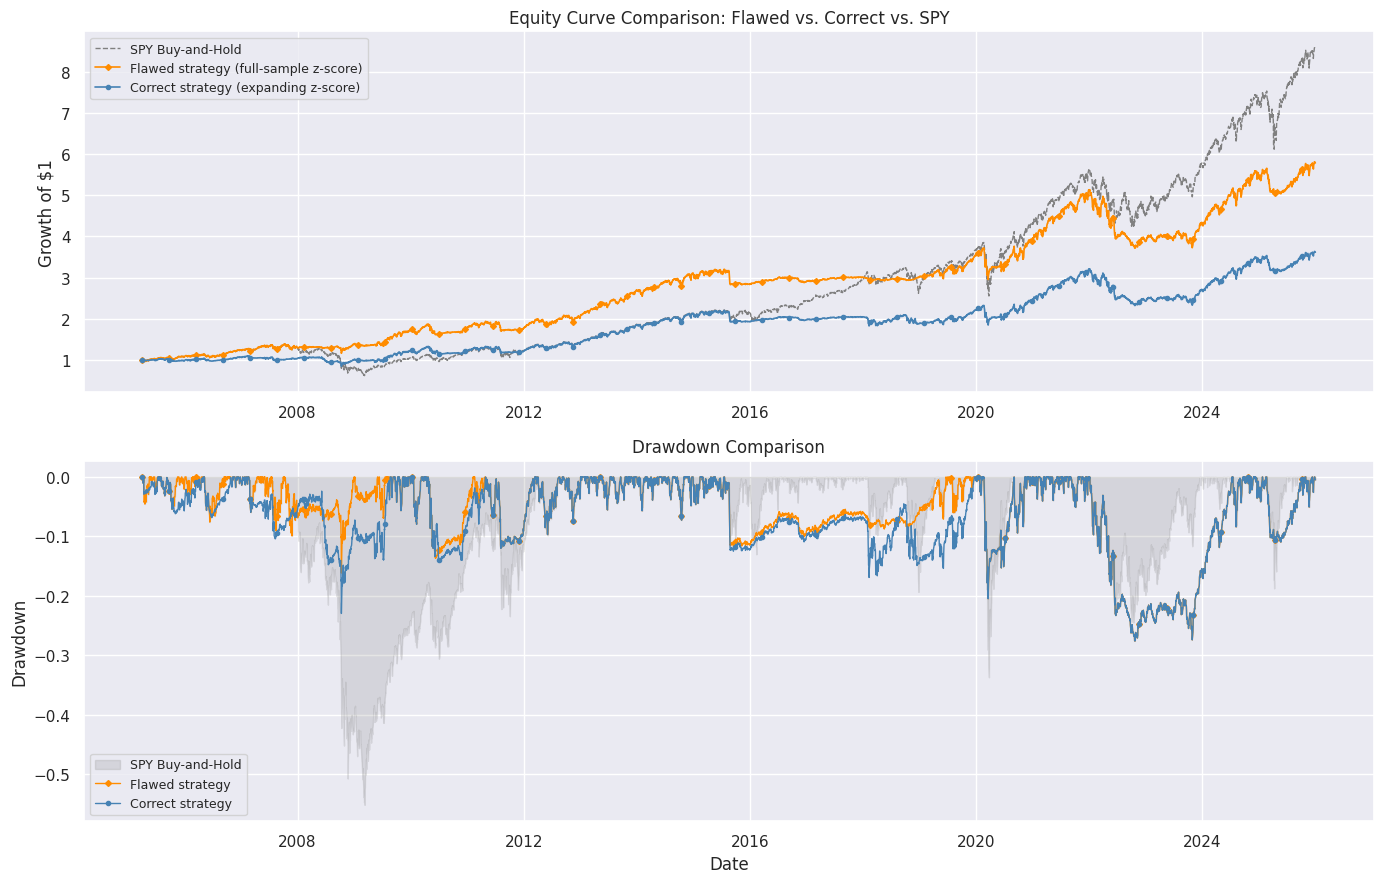


Before/After Comparison:

                                CAGR Sharpe Max Drawdown Win Rate
Strategy                                                         
SPY Buy-and-Hold              10.94%   0.54      -55.19%   55.35%
Flawed (full-sample z-score)   8.86%   0.70      -27.59%   54.93%
Correct (expanding z-score)    6.40%   0.50      -27.59%   54.51%


In [ ]:
# ── Equity curves ──────────────────────────────────────────────────────────────
# Both results already computed in Section 4. No rerun needed.
eq_flawed  = (1 + results_flawed['Strategy_Return']).cumprod()
eq_correct = (1 + results_correct['Strategy_Return']).cumprod()
eq_spy     = (1 + df['SPY_Return']).cumprod()

# Align all three to the same index
common_idx = eq_flawed.index.intersection(eq_correct.index).intersection(eq_spy.index)
eq_flawed  = eq_flawed.loc[common_idx]
eq_correct = eq_correct.loc[common_idx]
eq_spy     = eq_spy.loc[common_idx]

# ── Plot equity curves and drawdowns ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax1 = axes[0]
ax1.plot(eq_spy.index, eq_spy,
         color='gray', linewidth=1.0, linestyle='dashed',
         label='SPY Buy-and-Hold')
ax1.plot(eq_flawed.index, eq_flawed,
         color='darkorange', linewidth=1.2, linestyle='solid',
         marker='D', markersize=3, markevery=120,
         label='Flawed strategy (full-sample z-score)')
ax1.plot(eq_correct.index, eq_correct,
         color='steelblue', linewidth=1.2, linestyle='solid',
         marker='o', markersize=3, markevery=120,
         label='Correct strategy (expanding z-score)')

ax1.set_title('Equity Curve Comparison: Flawed vs. Correct vs. SPY')
ax1.set_ylabel('Growth of $1')
ax1.legend(loc='upper left', fontsize=9)

def compute_drawdown(eq):
    return (eq / eq.cummax() - 1)

dd_flawed  = compute_drawdown(eq_flawed)
dd_correct = compute_drawdown(eq_correct)
dd_spy     = compute_drawdown(eq_spy)

ax2 = axes[1]
ax2.fill_between(dd_spy.index, dd_spy, 0,
                 color='gray', alpha=0.2, label='SPY Buy-and-Hold')
ax2.plot(dd_flawed.index, dd_flawed,
         color='darkorange', linewidth=1.0, linestyle='solid',
         marker='D', markersize=3, markevery=120,
         label='Flawed strategy')
ax2.plot(dd_correct.index, dd_correct,
         color='steelblue', linewidth=1.0, linestyle='solid',
         marker='o', markersize=3, markevery=120,
         label='Correct strategy')

ax2.set_title('Drawdown Comparison')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_7_equity_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Before/after metrics table ─────────────────────────────────────────────────
def metrics_dict(returns, label, simple=True):
    """Return metrics dictionary for table construction."""
    if simple:
        log_rets = np.log(1 + returns.clip(lower=-0.9999))
        n_years  = len(returns) / 252
        cagr     = (1 + returns).prod() ** (1 / n_years) - 1
        sharpe   = (log_rets.mean() / log_rets.std()) * np.sqrt(252)
        eq       = (1 + returns).cumprod()
    else:
        n_years  = len(returns) / 252
        cagr     = np.exp(returns.sum() / n_years) - 1
        sharpe   = (returns.mean() / returns.std()) * np.sqrt(252)
        eq       = np.exp(returns.cumsum())
    drawdown = (eq / eq.cummax() - 1).min()
    win_rate = (returns > 0).sum() / (returns != 0).sum()
    return {'Strategy': label, 'CAGR': f"{cagr:.2%}",
            'Sharpe': f"{sharpe:.2f}", 'Max Drawdown': f"{drawdown:.2%}",
            'Win Rate': f"{win_rate:.2%}"}

rows = [
    metrics_dict(df['SPY_Return'].loc[common_idx], 'SPY Buy-and-Hold'),
    metrics_dict(results_flawed['Strategy_Return'].loc[common_idx],  'Flawed (full-sample z-score)'),
    metrics_dict(results_correct['Strategy_Return'].loc[common_idx], 'Correct (expanding z-score)'),
]

df_summary = pd.DataFrame(rows).set_index('Strategy')
print("\nBefore/After Comparison:\n")
print(df_summary.to_string())

The before/after comparison makes the impact of the flaw concrete:

- The flawed version reports a CAGR of 8.86% and Sharpe of 0.70
- The correct version delivers 6.40% CAGR and Sharpe of 0.50
- The gap is 246 bp of CAGR and 0.20 Sharpe, produced by a single normalization error
- Max drawdown is identical at -27.59%: the bias inflates returns without changing the risk profile

The equity curve tells the fuller story. The flawed version (orange) pulls ahead of the correct version (blue) consistently from the early period onward. The divergence is not concentrated in one event: it accumulates gradually over 20 years. That gradual accumulation is the signature of a normalization bias.

The drawdown panel confirms what the results audit already showed: both strategies manage risk similarly throughout. The flaw is entirely in the return generation, not the risk management. This is precisely why the results audit passed all five checks: there was nothing wrong with the risk profile to flag.

Two additional observations worth noting:

- Both strategies underperform SPY buy-and-hold on CAGR. The correct version particularly so. The paired switching concept has merit but this implementation needs further development before it would be worth deploying.
- The correct strategy still reduces max drawdown from -55.19% to -27.59% relative to SPY. There may be a real edge here. The normalization error just made it look much better than it is.

## Section 6: Key Takeaways

This notebook demonstrated a full forensic audit on a synthetic flawed backtest. The strategy was a paired switching rule on SPY and AGG using a momentum z-score signal with a full-sample normalization error baked in.

The audit process produced two important findings:

**The results audit passed everything:**
- Sharpe of 0.70: reasonable, not suspicious
- Win rate of 54.93%: realistic
- Max drawdown proportionate to CAGR
- Trade concentration well distributed
- Profitable in 77.4% of rolling 12-month periods

A standard results-based review would have approved this backtest. The numbers looked clean.

**The normalization audit found the flaw immediately:**
- `Z_Fullsample` flagged: mean of 0.000, std of 1.000 across the full series
- One line of code was the entire source of a 246 bp CAGR inflation and 0.20 Sharpe inflation

The broader lessons from this chapter:

- Lookahead bias does not always produce dramatic red flags in performance metrics
- The size of the distortion depends on the non-stationarity of the series being normalized: the SPY/AGG spread has a regime shift in 2022 that made the full-sample statistics particularly misleading
- A results audit and a normalization audit serve different purposes and both are necessary
- Any normalization step in a backtesting pipeline deserves scrutiny: was this statistic computable at the time of each trade?
- The correct methodology costs nothing extra to implement and is always the right choice regardless of how small the bias appears to be

The forensic audit function developed across notebooks 10.1 and 10.3 is a starting point. Adapt the thresholds to your own context and add checks as you encounter new failure modes in your own work.